In [1]:
from DFTStructureGenerator import B_N_Cl, xtb_process, mol_manipulation
import glob, os, shutil, itertools, copy
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Geometry import Point3D
import numpy as np
from tqdm import tqdm
import pandas as pd
from morfeus import BuriedVolume

In [2]:
from DFTStructureGenerator import B_N_Cl
import numpy as np
from tqdm import tqdm
import pandas as pd
from morfeus import BuriedVolume
from ase.db import connect

DB_PATH = "boron_ccl2.db"
db = connect(DB_PATH)


In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [6]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
import pickle
np.random.seed(0)

In [3]:
from matplotlib import pyplot as plt
def calc_distribution2(y, eachsize=0.01, title=None, xlab=None, ylab="Count", y_max=None, y_min=None):
    if y_max == None:    y_max = np.max(y)
    if y_min == None:    y_min = np.min(y)
    X = np.arange(y_min, y_max + eachsize, eachsize)
    des = [0 for each in X]
    z = (y - y_min)/eachsize
    for each in z:
        try:
            des[int(each)] += 1
        except:
            continue
    des = np.array(des)
    # des = des / len(y)
    
    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(111)
    ax.patch.set_alpha(0.0)
    plt.bar(X, des, width=eachsize/2, color="green")
    plt.xlim(y_min - eachsize, y_max + eachsize)
    plt.ylim(0, np.max(des) * 1.2)
    plt.xlabel(xlab, fontsize=30)
    plt.ylabel(ylab, fontsize=30)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    if title != None:
        plt.title = title
    plt.tight_layout()
    plt.savefig('test.svg', format='svg')
    plt.show()
    return des

def plot_scatter_with_metrics(x, y, title=None, min_=-10, max_=60):
    """
    Plot a scatter plot and display regression performance metrics
    
    parameter:
    x: One-dimensional array type, representing x-axis data.
    y: One-dimensional array type, representing y-axis data.
    title: String type, indicating the title of the figure.
    
    Return value:
    None
    
    """
    # Calculate regression performance metrics
    r2 = r2_score(x, y)
    mae = mean_absolute_error(x, y)
    mse = mean_squared_error(x, y)

    # Draw a scatter plot
    plt.figure(figsize=(5, 5))
    plt.xlim(min_, max_)
    plt.ylim(min_, max_)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    # plt.xlabel("Real", fontsize=18)
    # plt.ylabel("Prediction", fontsize=18)
    if title != None:
        plt.title("%s\nR2:%.3f, MAE:%.3f, MSE:%.3f" % (title, r2, mae, mse), fontsize=24)
        plt.title("%s"%title,fontsize=24)
    z = np.linspace(min_, max_, 10000)
    plt.plot(z, z)

    plt.scatter(x, y, marker="*", c="g")
    # Add regression performance metrics to the second row of the image
    
    # show image
    plt.savefig("test.svg", format="svg")
    plt.show()
def plot_plot_with_metrics(x, y, title=None, min_=None, max_=None):
    """
    Draw a line chart and display regression performance metrics
    
    parameter:
    x: One-dimensional array type, representing x-axis data.
    y: One-dimensional array type, representing y-axis data.
    title: String type, indicating the title of the figure.
    
    Return value:
    None
    
    """
    # Calculate regression performance metrics
    r2 = r2_score(x, y)
    mae = mean_absolute_error(x, y)
    mse = mean_squared_error(x, y)

    # Draw a scatter plot
    plt.figure(figsize=(7, 5))
    if min_ and max_:
        plt.xlim(min_, max_)
        plt.ylim(min_, max_)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    # plt.xlabel("Real", fontsize=18)
    # plt.ylabel("Prediction", fontsize=18)
    if title != None:
        plt.title("%s\nR2:%.3f, MAE:%.3f, MSE:%.3f" % (title, r2, mae, mse), fontsize=24)
        plt.title("%s"%title,fontsize=24)
    plt.plot(x, y, marker="*", c="g")
    # Add regression performance metrics to the second row of the image
    
    # show image
    plt.savefig("test.svg", format="svg")
    plt.show()

In [4]:
duplicate_N_id = [9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376]
duplicate_Cl_id = [624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 634, 635, 636,
       637, 638, 639, 640, 642, 644, 645, 652, 653, 654, 655, 656, 657, 658, 659, 660, 661, 662, 663, 664,
       665, 666, 667, 668, 669, 670, 671, 672, 673, 674, 675, 676, 677,
       678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690,
       691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 701, 702, 703,
       704, 705, 706, 707, 708, 709, 710, 711, 713, 714, 716, 717, 718, 719, 720, 721, 722]

In [ ]:



all_des_name = ["deltaG", "B_N Combination Energy", "B_N react deltaG", "B_N B_charge", "B_N N_charge", "B_N B_spin", "B_N N_spin", 
 "B_N B_Hirshfield_charge", "B_N N_Hirshfield_charge", "B_N B_N_dist", "B_N Alpha-HOMO-1", "B_N Alpha-HOMO", 
 "B_N Alpha-LUMO", "B_N Alpha-LUMO+1", "B_N Beta-HOMO-1", "B_N Beta-HOMO", "B_N Beta-LUMO", "B_N Beta-LUMO+1",
 "B_N dipole", "B_N MaxOtherCharge", "B_N MinOtherCharge", "B_N_Cl B_charge", "B_N_Cl N_charge", "B_N_Cl Cl_charge", 
 "B_N_Cl B_Hirshfield_charge", "B_N_Cl N_Hirshfield_charge", "B_N_Cl Cl_Hirshfield_charge", "B_N_Cl B_N_dist", 
 "B_N_Cl N_Cl_dist", "B_N_Cl B_N_Cl_angel", "B_N_Cl HOMO-1", "B_N_Cl HOMO", "B_N_Cl LUMO", "B_N_Cl LUMO+1", "B_N_Cl dipole",
 "B_N_Cl MaxOtherCharge", "B_N_Cl MinOtherCharge", "B_N_Cl MaxChargeDist", "B_N_Cl MinOtherChargeDist", 
 "B_N_Cl MaxOtherHCharge", "B_N_Cl MinOtherHCharge", "B_N_Cl MaxHChargeDist", "B_N_Cl MinHOtherChargeDist", 
 "B_N_Cl MaxAromaticRingCharge", "B_N_Cl MinAromaticRingCharge", "B_N_Cl MaxAromaticChargeDist", "B_N_Cl MinAromaticChargeDist",
 "B_N_Cl Bv2radius", "B_N_Cl Bv4radius", "B_N_Cl Bv6radius", 
 "C_Cl react deltaG", "C_Cl Cl_charge", "C_Cl C_charge", "C_Cl Cl_Hirshfield_charge", "C_Cl C_Hirshfield_charge", 
 "C_Cl MaxOtherCharge", "C_Cl MinOtherCharge", "C_Cl MaxChargeDist", "C_Cl MinOtherChargeDist", 
 "C_Cl MaxOtherHCharge", "C_Cl MinOtherHCharge", "C_Cl MaxHChargeDist", "C_Cl MinHOtherChargeDist", 
 "C_Cl MaxAromaticRingCharge", "C_Cl MinAromaticRingCharge", "C_Cl MaxAromaticChargeDist", "C_Cl MinAromaticChargeDist",
 "C_Cl C_Cl_dist", 
 "C_Cl HOMO-1", "C_Cl HOMO", "C_Cl LUMO", "C_Cl LUMO+1", "C_Cl dipole", "C_Cl Bv2radius", "C_Cl Bv4radius", "C_Cl Bv6radius", "C C_charge", "C C_spin", "C C_Hirshfield_charge", 
 "C Alpha-HOMO-1", "C Alpha-HOMO", "C Alpha-LUMO", "C Alpha-LUMO+1", "C Beta-HOMO-1", "C Beta-HOMO", "C Beta-LUMO", "C Beta-LUMO+1", "C_dipole"]


selected_des = ['deltaG'  'B_N B_spin'  'B_N B_Hirshfield_charge'  'B_N B_N_dist'
 'B_N Alpha-HOMO'  'B_N_Cl B_Hirshfield_charge'
 'B_N_Cl Cl_Hirshfield_charge'  'B_N_Cl N_Cl_dist'  'B_N_Cl LUMO'
 'B_N_Cl Bv6radius'  'C_Cl Cl_Hirshfield_charge'  'C_Cl C_Hirshfield_charge'
 'C_Cl C_Cl_dist'  'C_Cl LUMO'  'C_Cl Bv6radius'  'C C_spin'
 'C C_Hirshfield_charge'  'C Alpha-HOMO']

B_N_csv = pd.read_csv("data/csvs/reactants_B_N.csv")
B_N_des_map = {}
for line_id, line in tqdm(B_N_csv.iterrows()):

    B_Index = int(line['B_Index'])
    B_Atomid = int(line['B_Atomid'])
    B_smiles = line['B_smiles']
    N_Index = int(line['N_Index'])
    N_Atomid = int(line['N_Atomid'])
    N_smiles = line['N_smiles']
    react_eng = line['deltaG_react']
    B_N_name = f"B_{B_Index:05}_Nu_{N_Index:05}"
    if B_N_name in B_N_des_map:
        continue

    # Get the number of B single atoms from smiles, which is used to calculate the atom offset of N in the complex.
    B_mol = B_N_Cl.mol_manipulation.smiles2mol(B_smiles)
    B_atomnum = B_mol.GetNumAtoms()

    # Read complex_r and complex_p records from db
    react_key = f"B_{B_Index:05}_LB_{N_Index:05}_r"
    prod_key = f"B_{B_Index:05}_LB_{N_Index:05}_p"
    react_row = db.get(key=react_key)
    prod_row = db.get(key=prod_key)

    react_atoms = react_row.toatoms()
    prod_atoms = prod_row.toatoms()
    react_positions = react_atoms.get_positions()
    prod_positions = prod_atoms.get_positions()
    react_symbols = react_atoms.get_chemical_symbols()
    prod_symbols = prod_atoms.get_chemical_symbols()

    react_spin_densities = react_row.data.get("spin_densities")
    react_hirshfeld = react_row.data.get("hirshfeld_charges")
    prod_hirshfeld = prod_row.data.get("hirshfeld_charges")

    # BN react descriptor
    descriptor = [react_eng]
    descriptor += [react_spin_densities[B_Atomid]]
    descriptor += [react_hirshfeld[B_Atomid]]
    descriptor += [B_N_Cl.Tool.get_atoms_distance(react_positions[B_Atomid], react_positions[N_Atomid + B_atomnum - 1])]
    descriptor += [react_row.homo_energy_kcal]

    # BNCl product descriptor
    Cl_Index = prod_symbols.index("Cl")
    descriptor += [prod_hirshfeld[B_Atomid], prod_hirshfeld[Cl_Index]]
    descriptor += [B_N_Cl.Tool.get_atoms_distance(prod_positions[B_Atomid], prod_positions[Cl_Index])]
    descriptor += [prod_row.lumo_energy_kcal]

    bv = BuriedVolume(prod_symbols, prod_positions, B_Atomid + 1, include_hs=1, radius=6, z_axis_atoms=[Cl_Index + 1], excluded_atoms=[Cl_Index + 1])
    bv.octant_analysis()
    descriptor += [np.sum(list(bv.octants['percent_buried_volume'].values()))]
    
    B_N_des_map[B_N_name] = descriptor

Cl_csv = pd.read_csv("data/csvs/reactants_Cl.csv")
Cl_des_map = {}
for line_id, line in tqdm(Cl_csv.iterrows()):
    Cl_Index = line['Index']
    Cl_Atomid = line['Atomid']
    Cl_smiles = line['Smiles']
    react_eng = line['deltaG_react']

    # Get C atom index from smiles (neighbor of Cl )
    Cl_mol = B_N_Cl.mol_manipulation.smiles2mol(Cl_smiles)
    C_atom_idx = Cl_mol.GetAtomWithIdx(Cl_Atomid).GetNeighbors()[0].GetIdx()

    # Read Cl_r and c_radical (Cl_p) records from db
    react_key = f"Cl_{Cl_Index:05}_r"
    prod_key = f"Cl_{Cl_Index:05}_p"
    react_row = db.get(key=react_key)
    prod_row = db.get(key=prod_key)

    react_atoms = react_row.toatoms()
    prod_atoms = prod_row.toatoms()
    react_positions = react_atoms.get_positions()
    prod_positions = prod_atoms.get_positions()
    react_symbols = react_atoms.get_chemical_symbols()

    react_hirshfeld = react_row.data.get("hirshfeld_charges")
    prod_spin_densities = prod_row.data.get("spin_densities")
    prod_hirshfeld = prod_row.data.get("hirshfeld_charges")

    # C-Cl react descriptor
    descriptor = [react_eng]
    descriptor += [react_hirshfeld[Cl_Atomid], react_hirshfeld[C_atom_idx]]

    descriptor += [B_N_Cl.Tool.get_atoms_distance(react_positions[Cl_Atomid], react_positions[C_atom_idx])]
    descriptor += [react_row.lumo_energy_kcal]
    bv = BuriedVolume(react_symbols, react_positions, C_atom_idx + 1, include_hs=1, radius=6, z_axis_atoms=[Cl_Atomid + 1], excluded_atoms=[Cl_Atomid + 1])
    bv.octant_analysis()
    descriptor += [np.sum(list(bv.octants['percent_buried_volume'].values()))]

    # Cl product (C radical) descriptor
    if C_atom_idx > Cl_Atomid: C_atom_idx -= 1
    descriptor += [prod_spin_densities[C_atom_idx]]
    descriptor += [prod_hirshfeld[C_atom_idx]]
    descriptor += [prod_row.homo_energy_kcal]
    Cl_name = f"Cl_{Cl_Index:05}"
    if Cl_Index in duplicate_Cl_id:
        Cl_name = f"Cl_{Cl_Index:05}_Claid_{Cl_Atomid:05}"
    Cl_des_map[Cl_name] = descriptor

In [ ]:
with open("data/descriptor/Cldes_new2.pkl", 'wb') as f:
    pickle.dump(Cl_des_map, f)
with open("data/descriptor/BNdes_new2.pkl", 'wb') as f:
    pickle.dump(B_N_des_map, f)

# Feature filtering

In [7]:
with open("Data/descriptor/BNdes_new2.pkl", 'rb') as f:
    B_N_des_map = pickle.load(f)
with open("Data/descriptor/Cldes_new2.pkl", 'rb') as f:
    Cl_des_map = pickle.load(f)


# Training model

In [30]:
# Combined quantitative features
data_csv = pd.read_csv("E:\work\B_Cl_Nu\Sum\Borane_all.csv")
y = data_csv['deltaGa(kcal/mol)']
target_eng = data_csv['deltaGa(kcal/mol)']
all_Xs = []
def df_to_des(data_csv):
    all_Xs = []
    for line_id, line in tqdm(data_csv.iterrows()):
        B_Index = line['B_Index']
        N_Index = line['N_Index']
        Cl_Index = line['Cl_Index']
        Cl_Atomid = line['Cl_Atomid']
        B_N_name = f"B_{B_Index:05}_Nu_{N_Index:05}"
        Cl_name = f"Cl_{Cl_Index:05}"
        if Cl_Index in duplicate_Cl_id:
            Cl_name = f"Cl_{Cl_Index:05}_Claid_{Cl_Atomid:05}"
        des_a = B_N_des_map[B_N_name]
        des_b = Cl_des_map[Cl_name]
        deltaG = [(des_a[0] + des_b[0]) * 627.5]
        all_Xs.append(deltaG + des_a[1:] + des_b[1:])
    return all_Xs
all_Xs = df_to_des(data_csv)

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Jackie\AppData\Local\Temp\ipykernel_24724\3545885321.py:2: SyntaxWarning: invalid escape sequence '\w'
  data_csv = pd.read_csv("E:\work\B_Cl_Nu\Sum\Borane_all.csv")
9236it [00:00, 42175.65it/s]


In [10]:
np.array(all_Xs).shape

(9236, 18)

In [52]:
all_X = np.array(all_Xs)
y = data_csv['deltaGa(kcal/mol)'].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = [0 for _ in range(len(all_X))]
for train_ids, test_ids in list(kf.split(all_X)):
# for train_ids, test_ids in kf:
    print(len(train_ids), len(test_ids))
    model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
    # model = RandomForestRegressor()
    model.fit(all_X[train_ids], y[train_ids])
    y_pred = model.predict(all_X[test_ids])
    print(r2_score(y[test_ids], y_pred), mean_absolute_error(y[test_ids], y_pred), mean_squared_error(y[test_ids], y_pred))
    all_r2s.append(r2_score(y[test_ids], y_pred))
    for test_id, y_p in zip(test_ids, y_pred):
        all_pred[test_id] = y_p
print(np.mean(all_r2s))

7388 1848
0.9137992544074054 1.347883520297191 3.4300189656039604
7389 1847
0.9003976955073254 1.4516400499145765 4.075682955737012
7389 1847
0.9081886101202811 1.3627688929669721 3.4686852048777235
7389 1847
0.9082880200324441 1.3871874776322086 3.645025507363889
7389 1847
0.9131627961341707 1.3930936974918673 3.68948268189365
0.9087672752403254


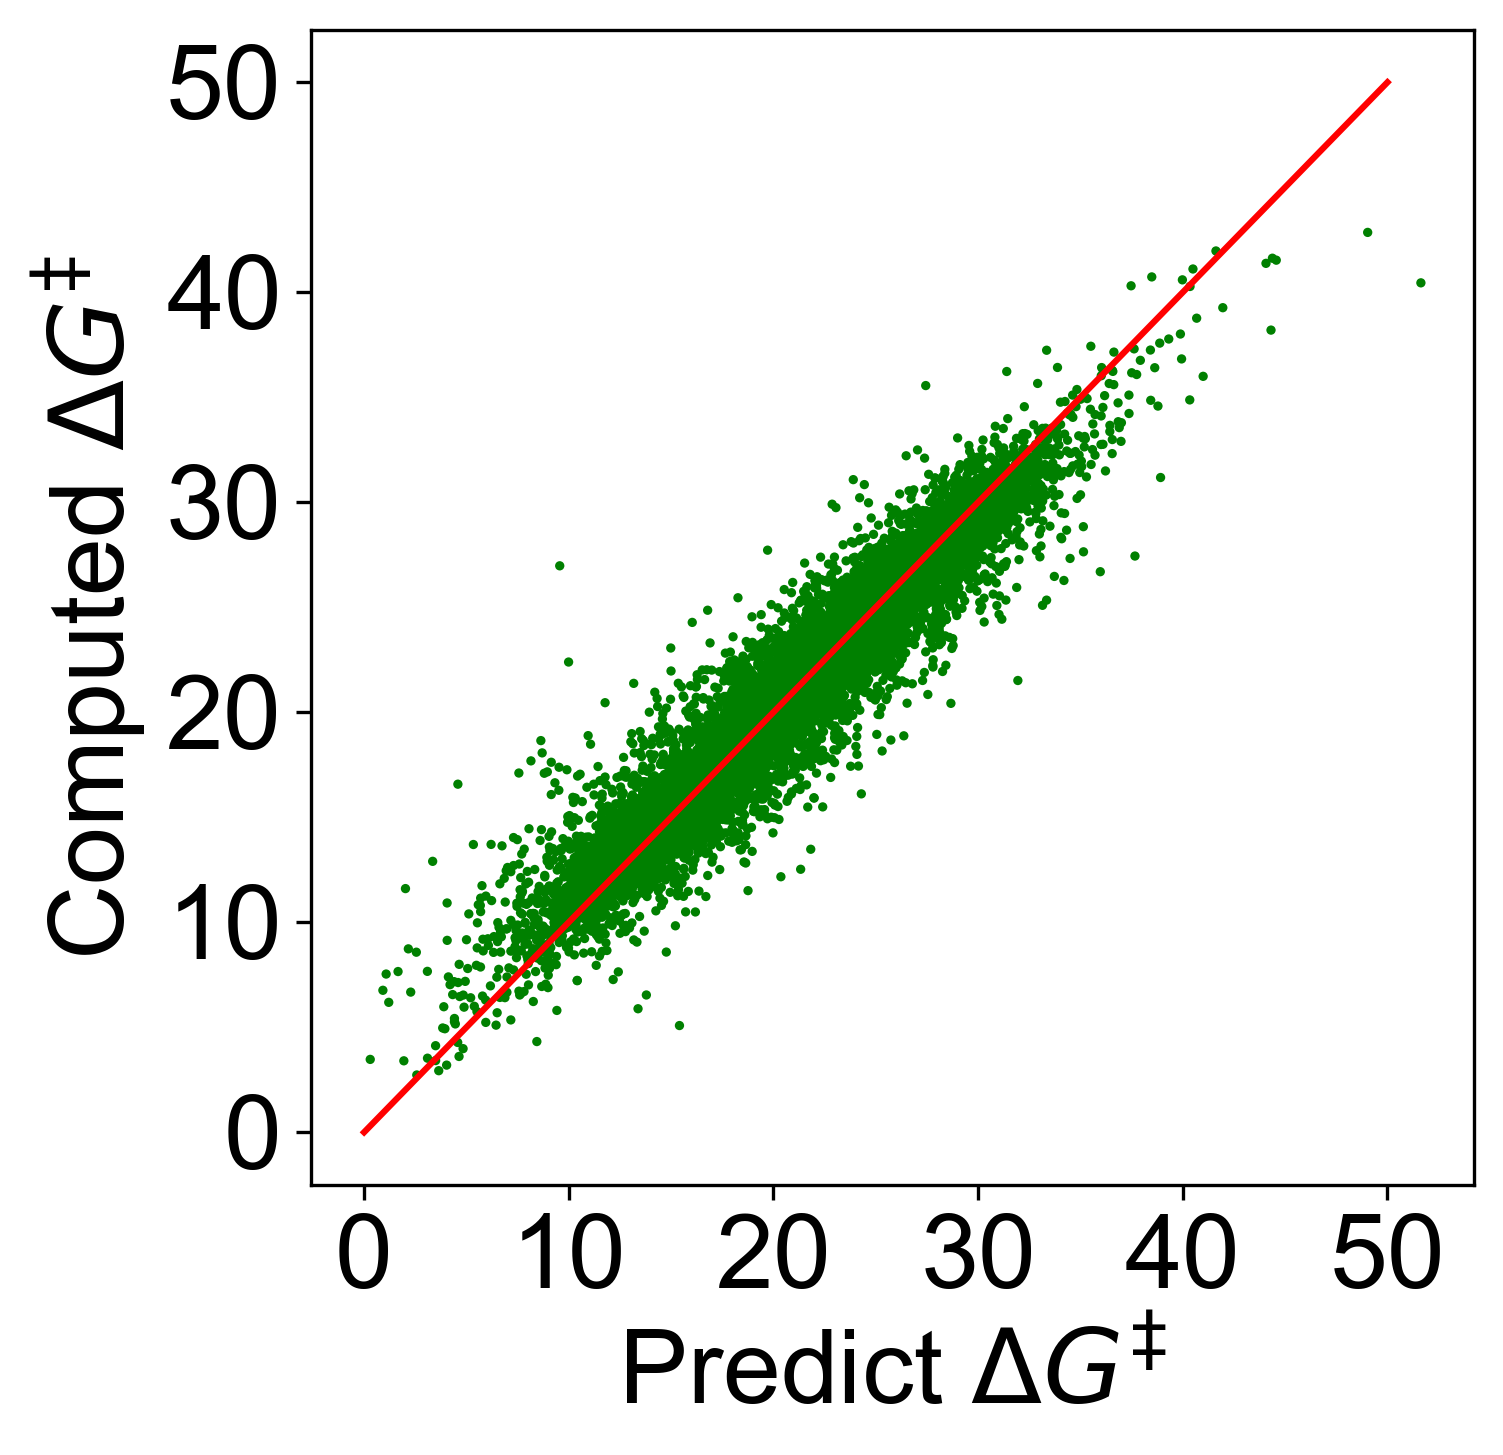

In [53]:
def plot_scatter_with_metrics(x, y, title=None, min_=None, max_=None):
    plt.figure(figsize=(5, 5), dpi=300)
    plt.rcParams['font.sans-serif'] = 'Arial'
    if min_ and max_:
        plt.xlim(min_, max_)
        plt.ylim(min_, max_)
    plt.xticks(fontsize=25)
    plt.yticks(fontsize=25)
    plt.scatter(x, y, s=5, c="g", alpha=1, edgecolors='none')
    plt.xlabel(r'Predict $\Delta G^{\ddagger}$', fontsize=25)
    plt.ylabel(r'Computed $\Delta G^{\ddagger}$', fontsize=25)
    plt.plot([min_,max_], [min_, max_], c='r')
    # plt.savefig("test.svg", format="svg")
    plt.show()
plot_scatter_with_metrics(y, all_pred, min_=0, max_=50)

In [43]:
def draw_correlation_map(X, figure_size=(5, 5), colors='coolwarm', useSVG=False, save_name='test', annot=True, show_label=False):
    # scaler = StandardScaler()
    # X = scaler.fit_transform(X)
    df = pd.DataFrame(X)
    correlation_matrix = np.abs(df.corr())
    # correlation_matrix = correlation_matrix.fillna(0)
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    print(np.max(correlation_matrix.to_numpy()[~mask]))
    f, ax = plt.subplots(figsize=figure_size, dpi=300)
    plt.rcParams['font.sans-serif'] = 'Arial'
    annot_kws = {"fontsize": 10}
    import seaborn as sns
    ax = sns.heatmap(correlation_matrix, 
            mask=mask,
            cmap='coolwarm',    
            annot=annot,         
            fmt='.1f',          
            center=0,           
            cbar=1,
            annot_kws=annot_kws,)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=25)
    cbar.ax.set_yticks(np.arange(0,1,0.2))
    if not show_label:
        ax.set_xticklabels('', fontsize=25)
        ax.set_yticklabels('', fontsize=25)
    plt.tight_layout()
    return correlation_matrix

In [33]:
all_X = np.concatenate([all_Xs, y.to_numpy().reshape(-1, 1)], axis=1)
all_X.shape, np.array(all_Xs).shape

((9236, 19), (9236, 18))

0.8949429795249786


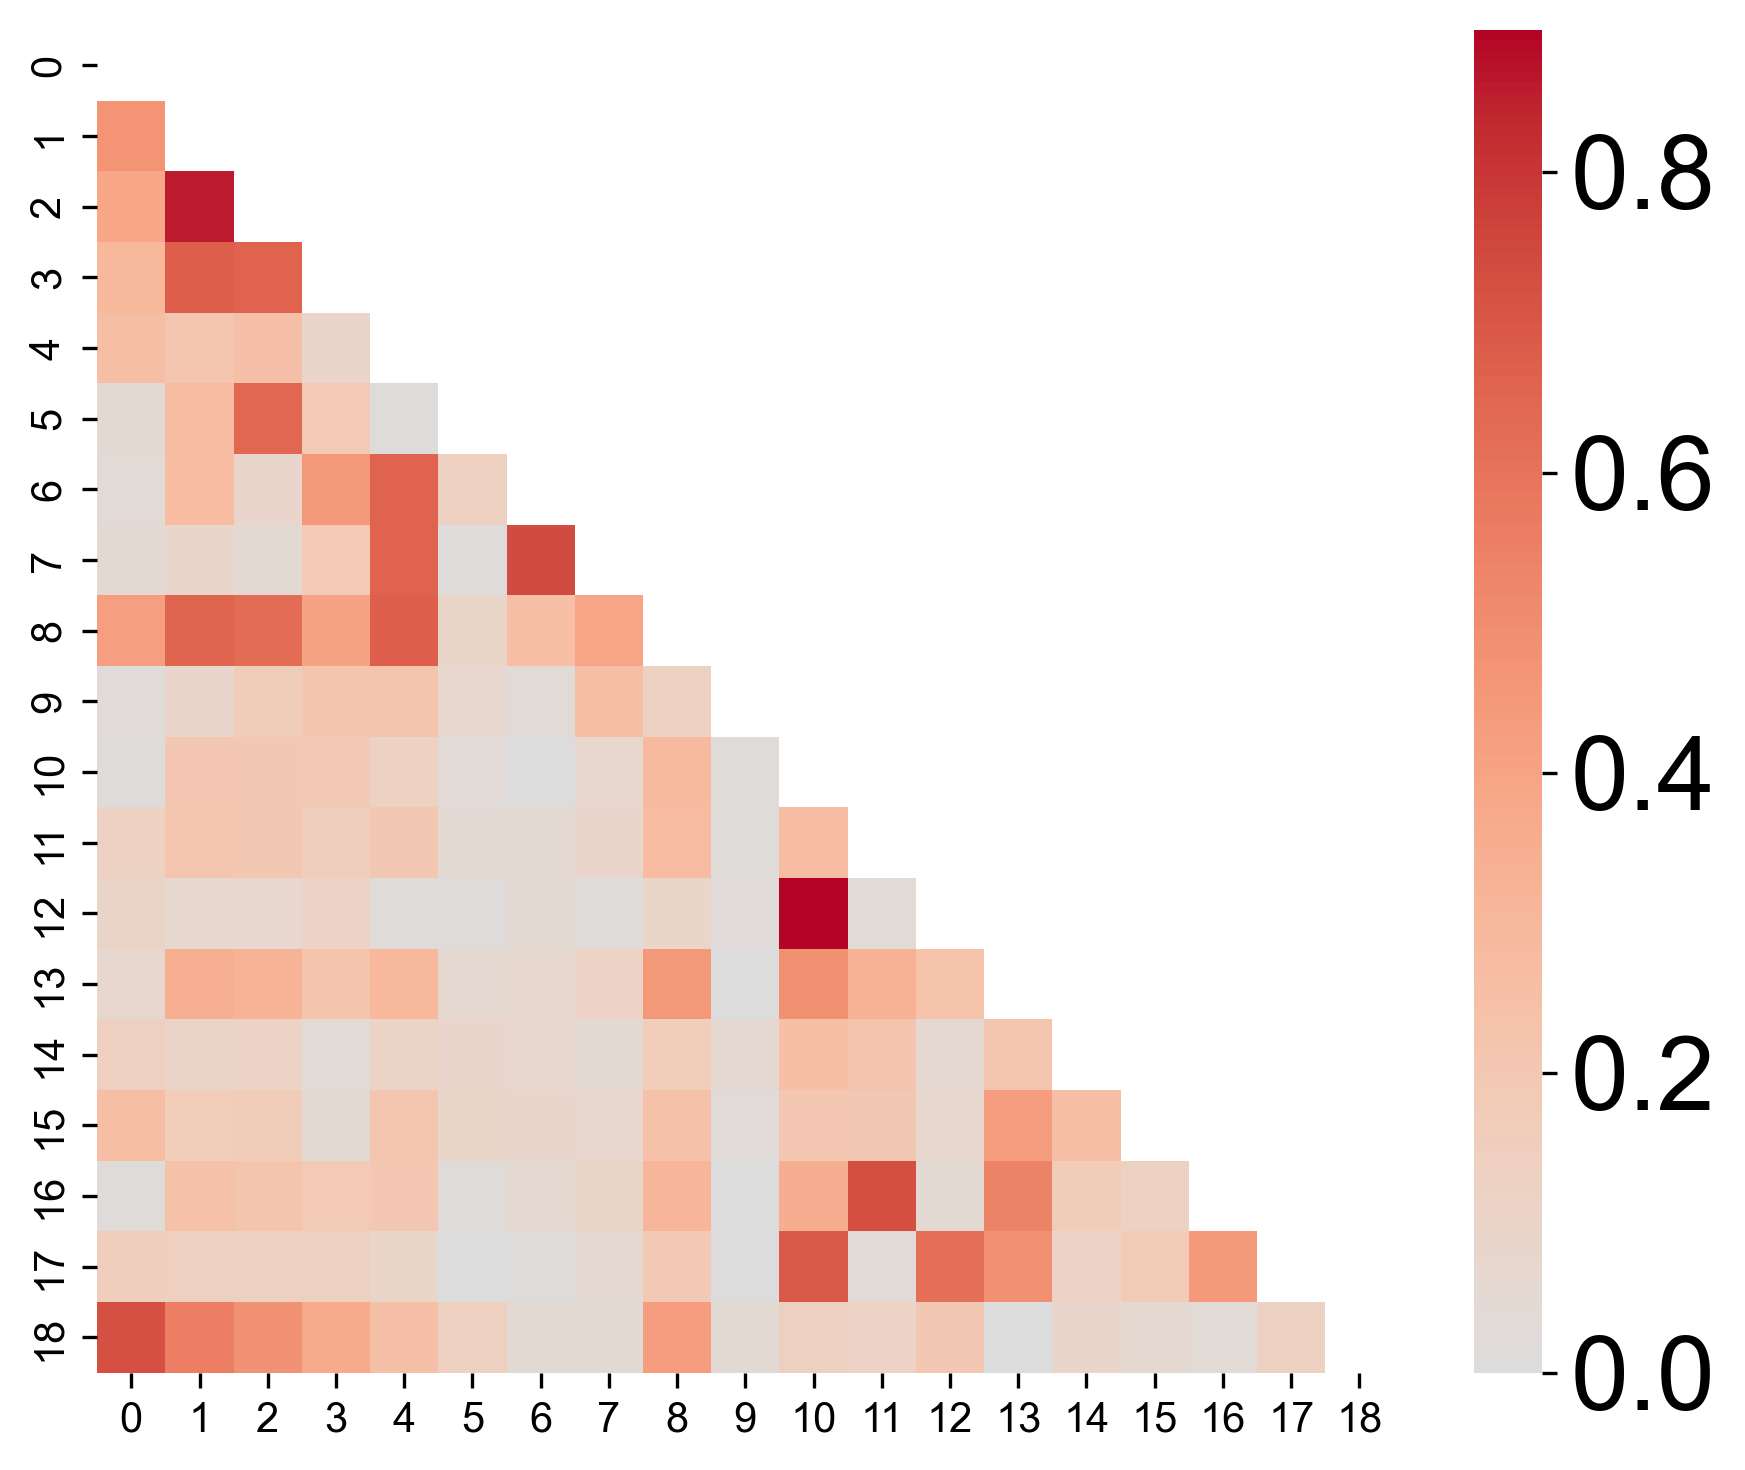

In [39]:
all_X = np.concatenate([all_Xs, y.to_numpy().reshape(-1, 1)], axis=1)
correlation_matrix = draw_correlation_map(all_X, figure_size=(6, 5), colors='coolwarm', useSVG=False, save_name='test', annot=False, show_label=True)

In [40]:
model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
model.fit(all_Xs, y)
FI = model.feature_importances_

In [41]:
des_name_std_sorted = [
    '$\\Delta G_{\\mathrm{rxn}}$',                 # deltaG
    'LB-B· $P^{\\mathrm{spin}}$',                  # B_N B_spin
    'LB-B· $q^{\\mathrm{B}}_{\\mathrm{H}}$',       # B_N B_Hirshfield_charge
    'LB-B· $d_{\\mathrm{LB-B}}$',                  # B_N B_N_dist
    'LB-B· $E_{\\mathrm{SOMO}}$',                  # B_N Alpha-HOMO
    'LB-B-Cl $q^{\\mathrm{B}}_{\\mathrm{H}}$',     # B_N_Cl B_Hirshfield_charge
    'LB-B-Cl $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',    # B_N_Cl Cl_Hirshfield_charge
    'LB-B· $d_{\\mathrm{B-Cl}}$',                  # B_N_Cl N_Cl_dist
    'LB-B-Cl $E_{\\mathrm{LUMO}}$',                # B_N_Cl LUMO
    'LB-B-Cl $\\%V_{\\mathrm{bur}}$',              # B_N_Cl Bv6radius
    'Cl-C $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',       # C_Cl Cl_Hirshfield_charge
    'Cl-C $q^{\\mathrm{C}}_{\\mathrm{H}}$',        # C_Cl C_Hirshfield_charge
    'Cl-C $d_{\\mathrm{Cl-C}}$',                   # C_Cl C_Cl_dist
    'Cl-C $E_{\\mathrm{LUMO}}$',                   # C_Cl LUMO
    'C_Cl $\\%V_{\\mathrm{bur}}$',                 # C_Cl Bv6radius
    'C· $P^{\\mathrm{spin}}$',                     # C C_spin
    'C· $q^{\\mathrm{C}}_{\\mathrm{H}}$',          # C C_Hirshfield_charge
    'C· $E_{\\mathrm{SOMO}}$'                      # C Alpha-HOMO
]

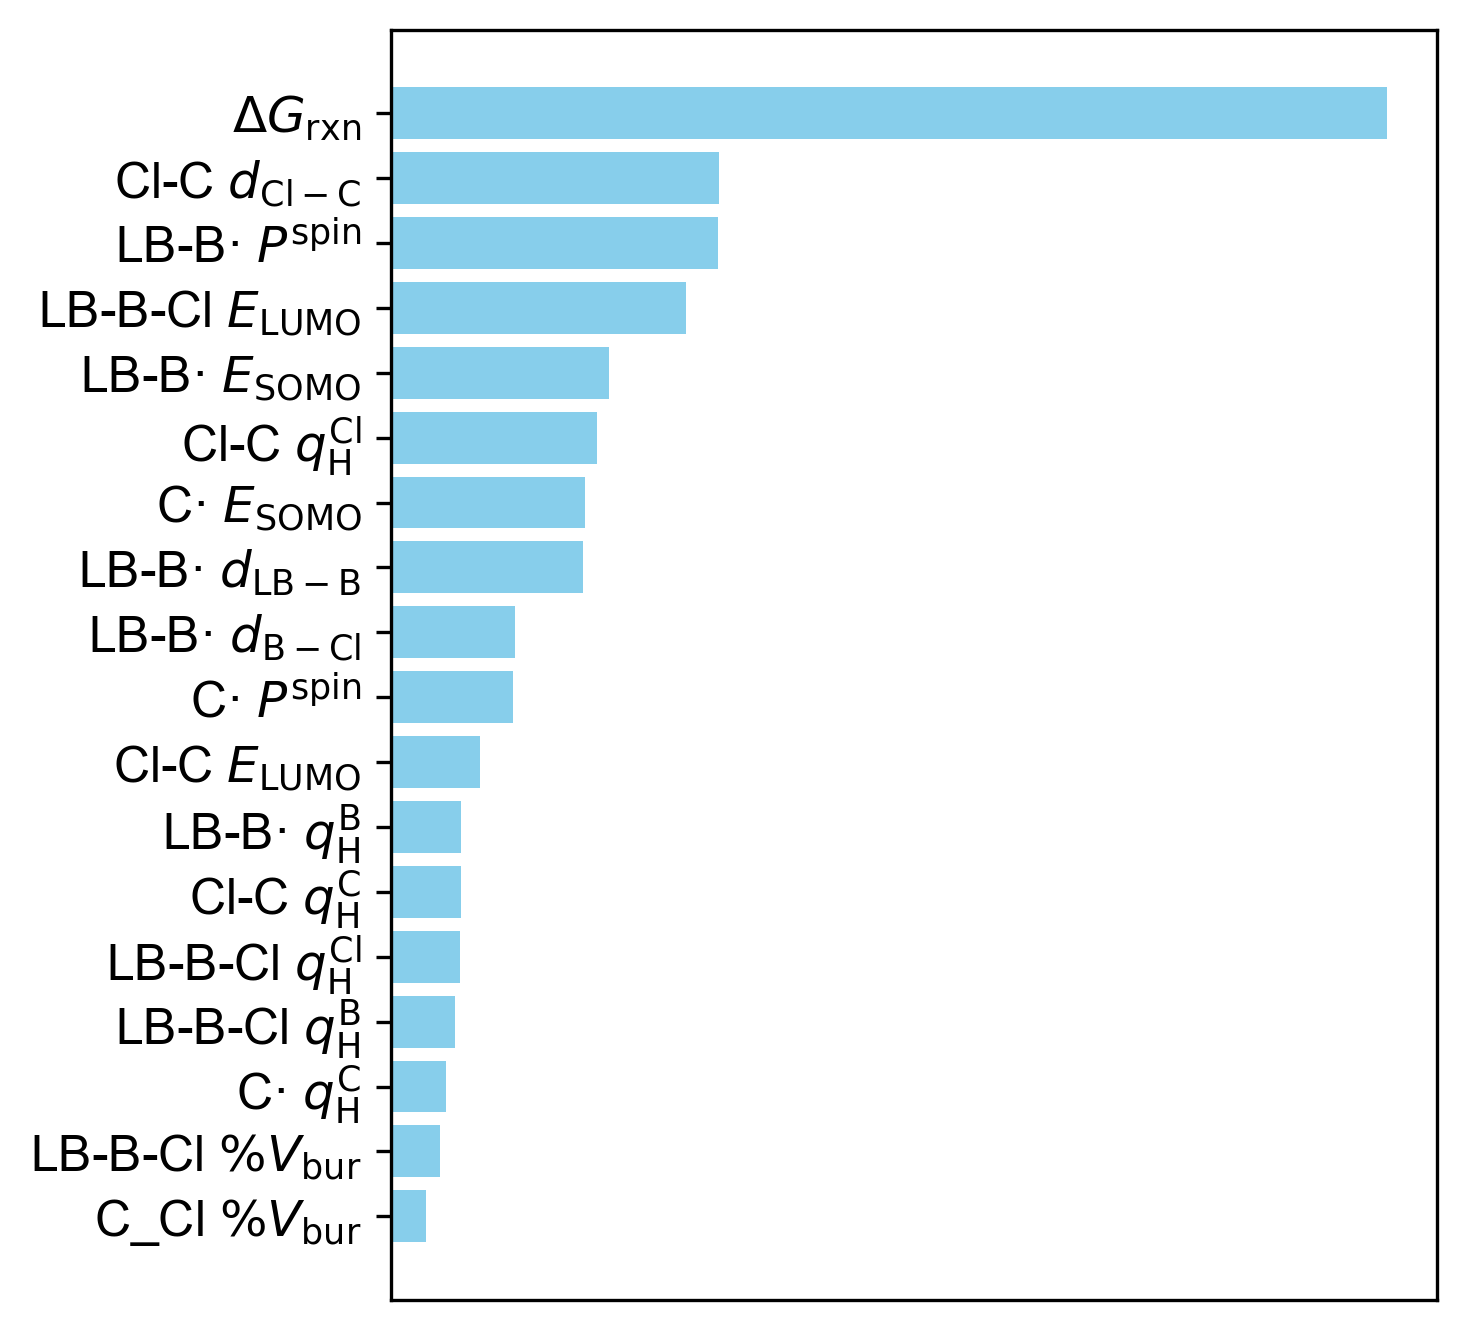

In [49]:
plt.figure(figsize=(4.5,5.5), dpi=300)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.barh(np.array(des_name_std_sorted)[np.argsort(FI)], np.sort(FI), color='skyblue')
# plt.xlabel('Feature Importance')
plt.xticks([])
plt.yticks(fontsize=12)
# plt.ylabel('Features')
# plt.title('Feature Importances')
plt.savefig("Ignored/Feature_Importance.png", dpi=300, bbox_inches='tight')

# OOD

## OOD around chlorine substrates

7237it [00:00, 39595.64it/s]
1999it [00:00, 36204.63it/s]
7496it [00:00, 40004.66it/s]
1740it [00:00, 43013.18it/s]
7567it [00:00, 39814.36it/s]
1669it [00:00, 42132.88it/s]
7409it [00:00, 41477.71it/s]
1827it [00:00, 42301.22it/s]
7235it [00:00, 39712.24it/s]
2001it [00:00, 39936.82it/s]


R2: 0.8109193524922607 MAE: 1.8995295107363668


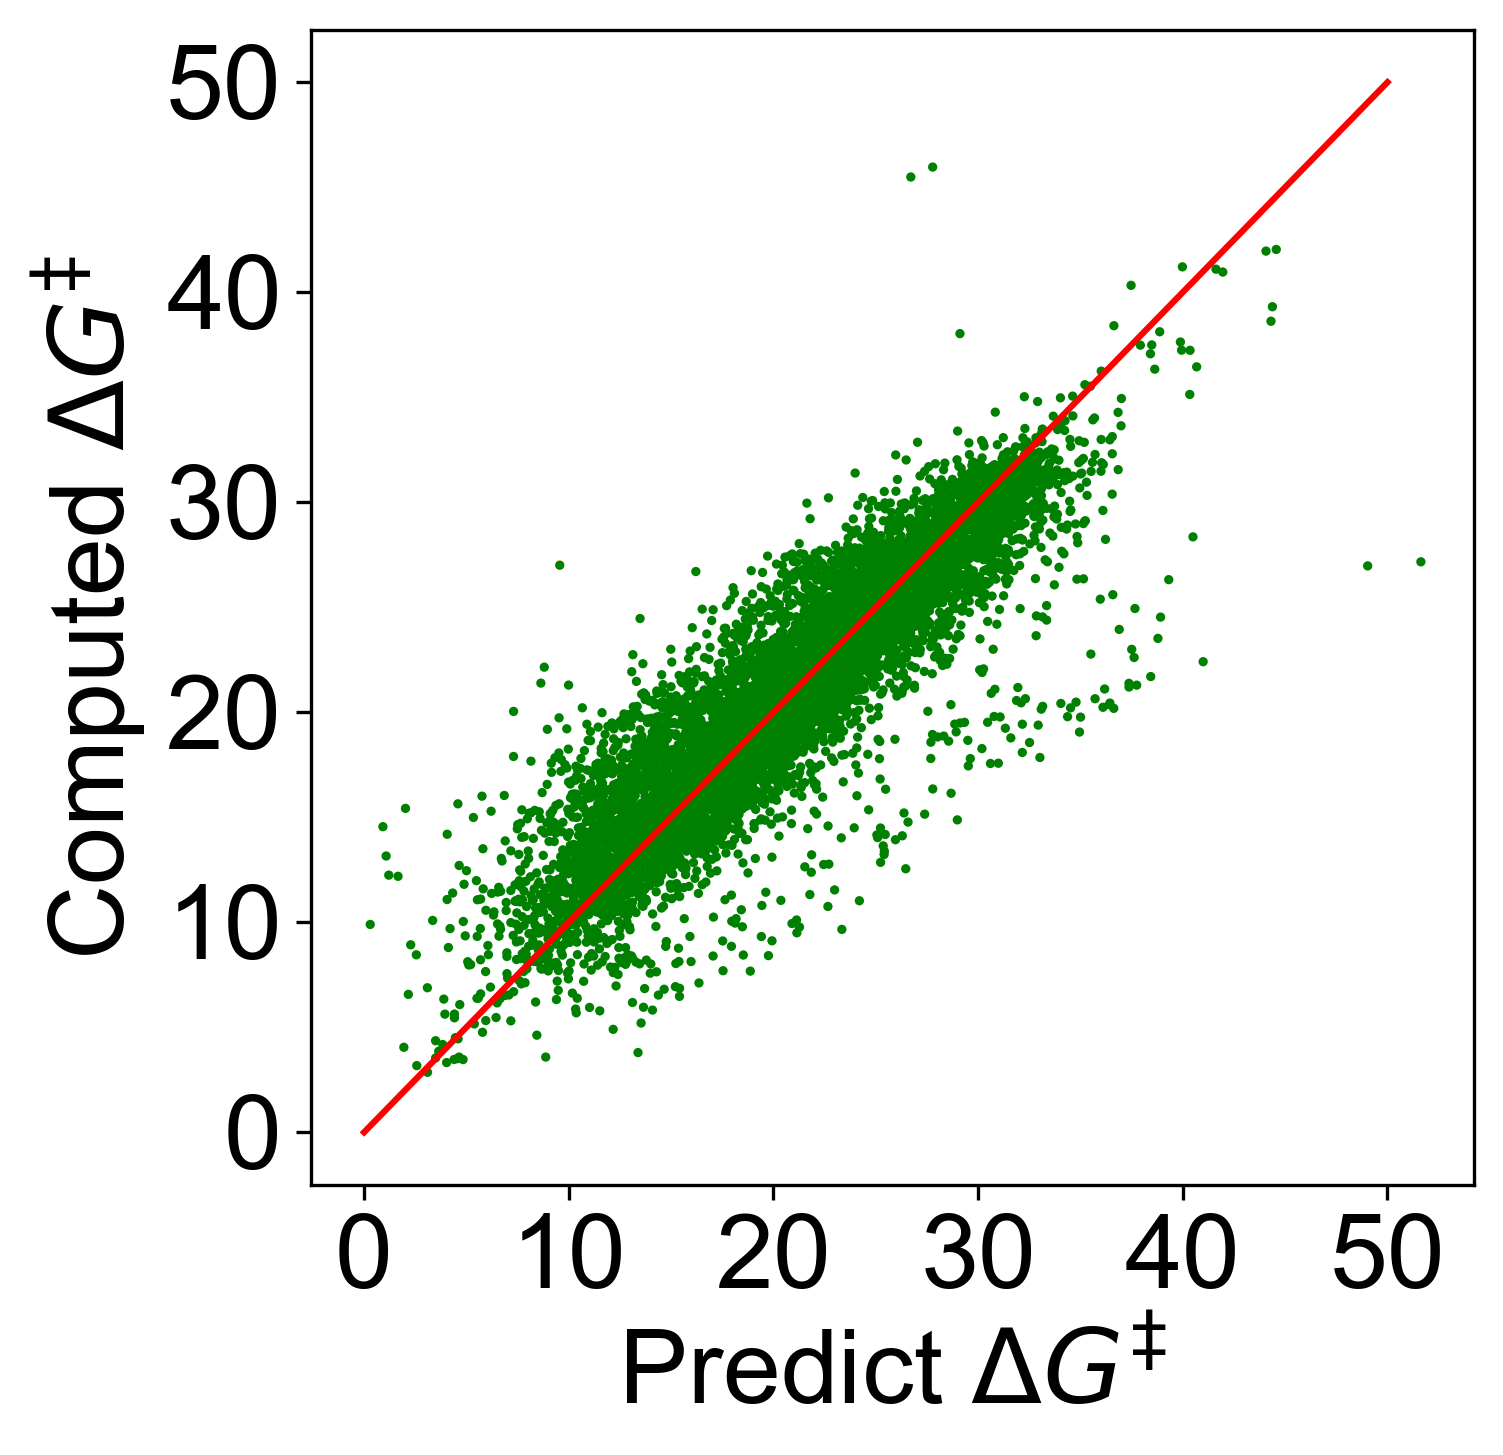

In [51]:
Cl_Indexs = np.sort(data_csv['Cl_Index'].unique())
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s, all_maes = [], []
all_pred = []
all_real = []
for i, (train_index, test_index) in enumerate(kf.split(Cl_Indexs)):
    train_Cl_index = Cl_Indexs[train_index]
    test_Cl_index = Cl_Indexs[test_index]
    train_df = data_csv.loc[data_csv['Cl_Index'].isin(train_Cl_index)].reset_index(drop=True)
    test_df = data_csv.loc[data_csv['Cl_Index'].isin(test_Cl_index)].reset_index(drop=True)
    train_X = df_to_des(train_df)
    test_X = df_to_des(test_df)
    train_y = train_df['deltaGa(kcal/mol)']
    test_y = test_df['deltaGa(kcal/mol)']

    model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
    model.fit(train_X, train_y)
    y_pred = model.predict(test_X)
    all_r2s.append(r2_score(test_y, y_pred))
    all_maes.append(mean_absolute_error(test_y, y_pred))
    all_pred.extend(y_pred)
    all_real.extend(test_y.to_numpy())
print("R2:", np.mean(all_r2s), "MAE:", np.mean(all_maes))
plot_scatter_with_metrics(np.array(all_real), np.array(all_pred), min_=0, max_=50)